In [1]:
# Import data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("Capstone_data_train_FD001.csv")

print("Dataset Shape:", train.shape)
train.head()

Dataset Shape: (20631, 26)


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Basic dataset information

print("Dataset Shape:", train.shape)

train.info()

Dataset Shape: (20631, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 

In [3]:
# Summary statistics

train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


In [4]:
# Check missing values

missing_values = train.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
# Check duplicate rows

print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [6]:
# Create Remaining Useful Life target variable

max_cycle = train.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

train = train.merge(max_cycle, on='unit_number', how='left')

train['RUL'] = train['max_cycle'] - train['time_cycles']

train.drop(columns=['max_cycle'], inplace=True)

train.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [7]:
print("Dataset Shape After RUL Creation:", train.shape)

train[['unit_number', 'time_cycles', 'RUL']].head(10)

Dataset Shape After RUL Creation: (20631, 27)


,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


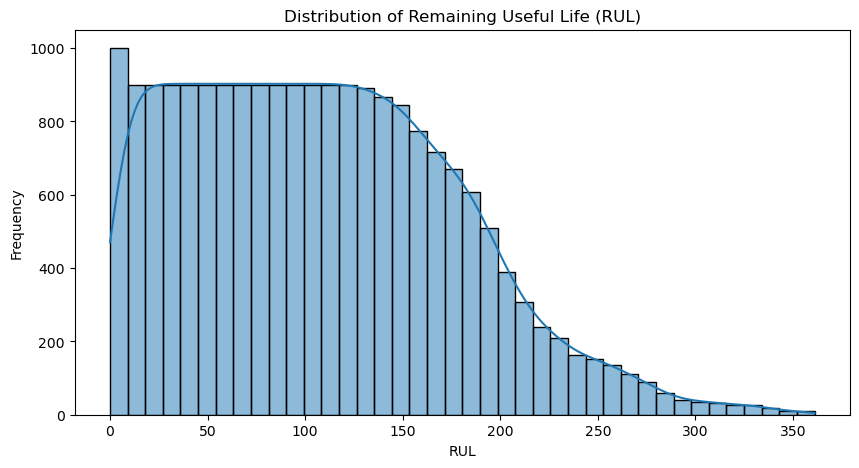

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(train['RUL'], bins=40, kde=True)

plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('RUL')
plt.ylabel('Frequency')

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


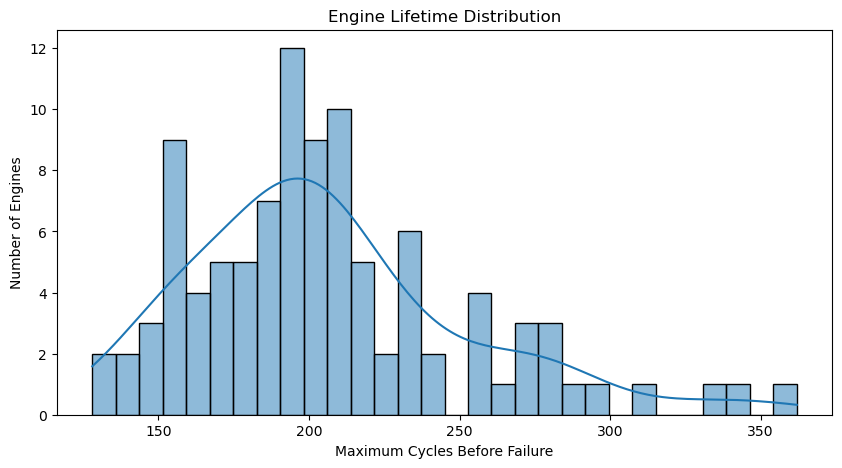

In [9]:
engine_life = train.groupby('unit_number')['time_cycles'].max()

plt.figure(figsize=(10,5))

sns.histplot(engine_life, bins=30, kde=True)

plt.title('Engine Lifetime Distribution')
plt.xlabel('Maximum Cycles Before Failure')
plt.ylabel('Number of Engines')

plt.show()

In [10]:
corr = train.corr(numeric_only=True)

rul_corr = (
    corr['RUL']
    .sort_values(ascending=False)
)

print(rul_corr.head(15))

RUL            1.000000
sensor_12      0.671983
sensor_7       0.657223
sensor_21      0.635662
sensor_20      0.629428
unit_number    0.078753
setting_2     -0.001948
setting_1     -0.003198
sensor_6      -0.128348
sensor_14     -0.306769
sensor_9      -0.390102
sensor_13     -0.562569
sensor_8      -0.563968
sensor_3      -0.584520
sensor_17     -0.606154
Name: RUL, dtype: float64


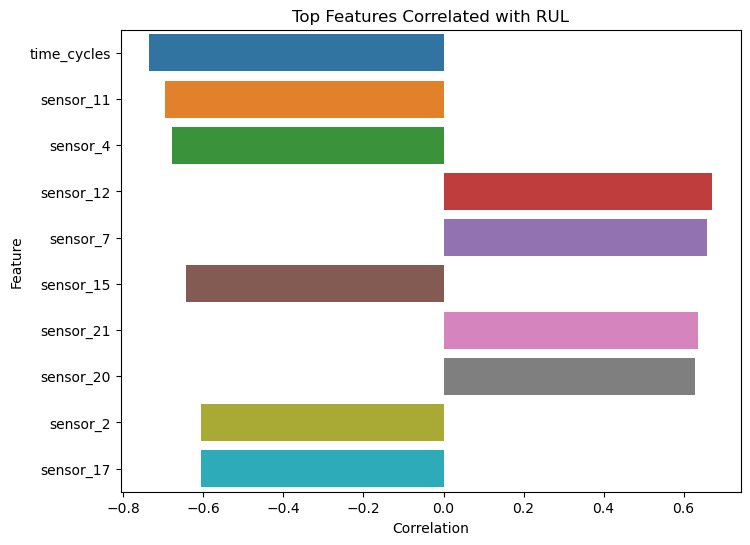

In [11]:
top_features = (
    rul_corr.abs()
    .sort_values(ascending=False)
    .index[1:11]
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=rul_corr[top_features],
    y=top_features
)

plt.title('Top Features Correlated with RUL')
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.show()

In [12]:
# Remove constant sensor

constant_cols = []

for col in train.columns:
    if train[col].nunique() == 1:
        constant_cols.append(col)

print("Constant Columns:")
print(constant_cols)

Constant Columns:
['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [13]:
#Drop Constant Features

train = train.drop(columns=constant_cols)

print(train.shape)

(20631, 20)


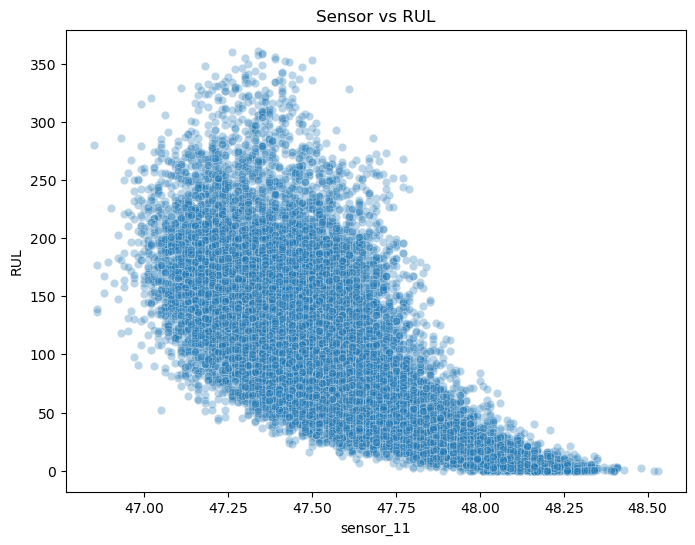

In [14]:
# Plot RUL vs Most Important Sensor

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train,
    x='sensor_11',   # replace with best sensor
    y='RUL',
    alpha=0.3
)

plt.title('Sensor vs RUL')
plt.show()

In [15]:
# Remove ID Column


train_model = train.copy()

train_model.drop(columns=['unit_number'], inplace=True)

In [16]:
# Define Features and Target

X = train_model.drop(columns=['RUL'])

y = train_model['RUL']

print(X.shape)
print(y.shape)

(20631, 18)
(20631,)


In [17]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(16504, 18)
(4127, 18)


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [19]:
y_pred = rf_model.predict(X_valid)

print(y_pred[:10])

[109.81   9.18 202.47   1.48 119.97 114.11 117.2   81.14 103.2  144.13]


In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_valid, y_pred)

rmse = mean_squared_error(
    y_valid,
    y_pred,
    squared=False
)

r2 = r2_score(y_valid, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 25.45
RMSE: 35.93
R²  : 0.7174


In [21]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
0,time_cycles,0.539977
10,sensor_11,0.141879
9,sensor_9,0.042552
5,sensor_4,0.039765
11,sensor_12,0.032108
13,sensor_14,0.024544
7,sensor_7,0.023563
14,sensor_15,0.021191
17,sensor_21,0.020496
3,sensor_2,0.019089


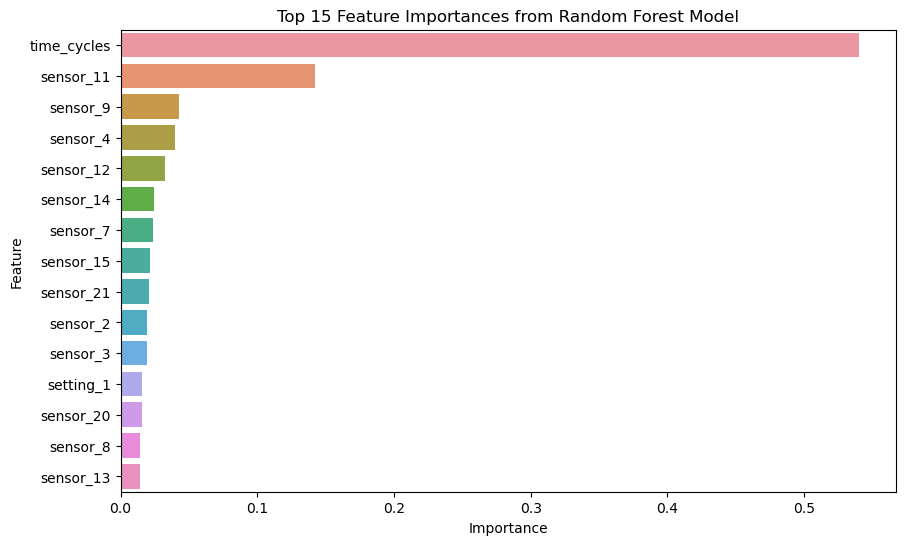

In [22]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

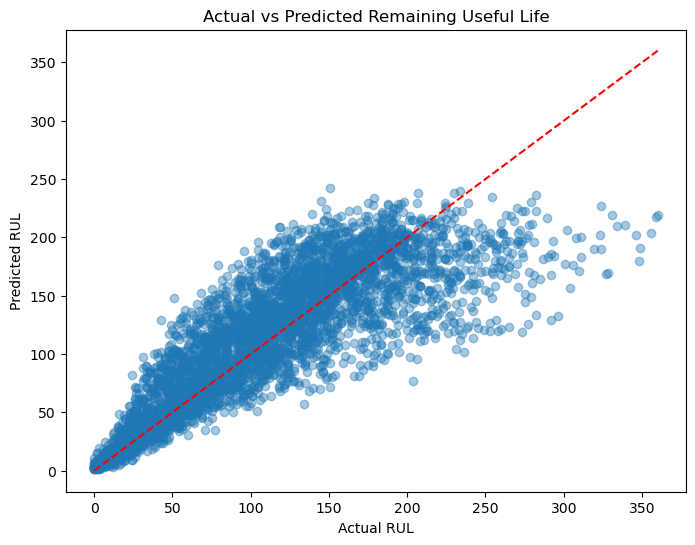

In [23]:
# Actual vs Predicted RUL

plt.figure(figsize=(8,6))

plt.scatter(
    y_valid,
    y_pred,
    alpha=0.4
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    'r--'
)

plt.title('Actual vs Predicted Remaining Useful Life')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')

plt.show()

In [24]:
## Baseline Model Results

A Random Forest Regressor was used as the baseline machine learning model for predicting Remaining Useful Life (RUL). 
This model was selected because it can capture non-linear relationships between engine sensor readings and degradation patterns.

The model achieved the following results:

- MAE: 25.45 cycles
- RMSE: 35.93 cycles
- R²: 0.7174

RMSE was selected as the primary evaluation metric because large prediction errors are costly in predictive maintenance. 
    A high RUL error could cause maintenance to be scheduled too early or too late. MAE was also reported because it gives the average prediction error in cycles, which is easy to interpret.

The R² score of 0.7174 indicates that the model explains approximately 71.7% of the variation in Remaining Useful Life. 
This provides a strong baseline for comparison with more advanced models in Module 24.

SyntaxError: invalid character '²' (U+00B2) (3057832308.py, line 10)

In [ ]:
## Initial Findings

The dataset contained 20,631 observations and no missing or duplicate values. The Remaining Useful Life target variable was created by 
subtracting each engine cycle from the maximum cycle for that engine.

EDA showed that RUL is right-skewed, with most observations occurring below 200 cycles. Engine lifetimes varied across units, 
with most engines failing between approximately 170 and 230 cycles.

Correlation analysis showed that several sensors had meaningful relationships with RUL. 
The strongest positive correlations included sensor_12, sensor_7, sensor_21, and sensor_20. 
Strong negative correlations included sensor_17, sensor_15, sensor_2, and sensor_4. 
These features appear to be useful indicators of equipment degradation.

Constant or low-information columns were removed before modeling. The Random Forest baseline model produced reasonable predictive 
performance and will be used as the benchmark for future modeling work.
